# Notebook 1: Carga y preparación inicial de datos

Este notebook:
1. Carga el histórico completo del S&P 500
2. Valida el universo (composición y cobertura temporal)
3. Filtra al periodo de interés
4. Limpia símbolos y resuelve colisiones
5. Selecciona 20 activos con criterio sectorial (histórico completo + liquidez + diversidad de sector)
6. Calcula retornos diarios logarítmicos
7. Revisa correlaciones y valores extremos (sanity check)
8. Guarda el dataset procesado

La lógica pesada vive en `src/data/`; aquí solo orquestamos y visualizamos.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_sp500_history, filter_period, summarize_universe
from src.data.cleaning import normalize_symbols, resolve_symbol_collisions
from src.data.selection import select_liquid_assets_by_sector, compute_daily_log_returns

## 1. Carga del histórico completo

In [2]:
df = load_sp500_history("../data/raw/sp500_history.parquet")
df.head()

,date,symbol,assetid,security_name,sector,industry,subsector,in_sp500,open,high,low,close,volume,unadjusted_close
0,1990-01-02,AAL-199702,259078,Alexander & Alexander Services Inc Common,Financials,Insurance,NaN,1,24.765203,25.682434,24.765203,25.682434,4.145635e+04,31.50
1,1990-01-02,AAMRQ-201312,127691,AMR Corp Common,Industrials,Passenger Airlines,Passenger Airlines,1,12.304145,12.648131,12.277684,12.648131,3.148086e+06,59.75
2,1990-01-02,AAPL,136817,Apple Inc Common,Information Technology,"Technology Hardware, Storage & Peripherals","Technology Hardware, Storage & Peripherals",1,0.246931,0.262693,0.245180,0.260942,2.334998e+08,37.25
3,1990-01-02,AAV-199901,260956,Avatex Corp Common,Financials,Financial Services,Multi-Sector Holdings,1,13.964755,14.205526,13.603598,13.964755,6.074220e+04,14.50
4,1990-01-02,ABI-200811,136309,Applied Biosystems Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,1,4.056182,4.236457,4.056182,4.236457,9.235902e+05,23.50


## 2. Validación del universo

In [3]:
summary = summarize_universe(df)
print(f"Activos totales en el histórico: {summary['n_activos_totales']}")
print(f"Activos que han pertenecido al S&P 500 en algún momento: {summary['n_activos_en_indice_alguna_vez']}")

Activos totales en el histórico: 1289
Activos que han pertenecido al S&P 500 en algún momento: 1289


## 3. Filtrado al periodo de interés

Usamos el mismo periodo de backtest que nos dio Eugeni: desde el 1 de enero de 2015.

In [4]:
START_DATE = "2015-01-01"
END_DATE = df["date"].max().strftime("%Y-%m-%d")

df_period = filter_period(df, start_date=START_DATE, warmup_months=0)
print("Rango:", df_period["date"].min(), "->", df_period["date"].max())

Rango: 2015-01-02 00:00:00 -> 2026-01-30 00:00:00


## 4. Limpieza de símbolos

In [5]:
df_clean = normalize_symbols(df_period)
df_clean = resolve_symbol_collisions(df_clean)
print(f"Filas antes: {len(df_period)}, después de limpiar: {len(df_clean)}")

Filas antes: 1962222, después de limpiar: 1961489


## 5. Selección de 20 activos por sector

**Decisión:** repartimos los 20 activos entre sectores (no solo por liquidez) para
poder simular después shocks sectoriales realistas (p.ej. "más volatilidad en
banca" necesita varios bancos, no solo uno).

**Decisión sobre sesgo de supervivencia:** exigimos histórico completo (~98% de
las fechas del periodo) para cada activo. Esto introduce sesgo de supervivencia
residual (excluye empresas que desaparecieron del todo), pero lo asumimos
conscientemente: los modelos generativos necesitan series alineadas sin huecos,
y como la comparación entre métodos (real vs. real+sintético) es siempre sobre
el mismo universo, el sesgo afecta por igual a todos los brazos del experimento
y no distorsiona la conclusión de cuál método funciona mejor.

In [6]:
df_clean["sector"].unique()

<ArrowStringArray>
[           'Health Care', 'Consumer Discretionary',            'Industrials',
 'Information Technology',             'Financials',       'Consumer Staples',
              'Utilities',            'Real Estate',              'Materials',
                 'Energy', 'Communication Services',                      nan]
Length: 12, dtype: str

In [7]:
sectores_deseados = {
    "Financials": 5,
    "Energy": 3,
    "Information Technology": 3,
    "Health Care": 2,
    "Consumer Discretionary": 2,
    "Industrials": 2,
    "Consumer Staples": 1,
    "Utilities": 1,
    "Materials": 1,
}

selected_assets = select_liquid_assets_by_sector(
    df_clean, start_date=START_DATE, end_date=END_DATE, n_per_sector=sectores_deseados
)
selected_assets

['BAC',
 'WFC',
 'C',
 'HBAN',
 'KEY',
 'XOM',
 'KMI',
 'RIG',
 'NVDA',
 'AAPL',
 'AMD',
 'PFE',
 'BMY',
 'TSLA',
 'F',
 'AAL',
 'CSX',
 'WMT',
 'PCG',
 'FCX']

## 6. Retornos diarios logarítmicos

In [8]:
returns = compute_daily_log_returns(df_clean, selected_assets)
returns.head()

symbol,AAL,AAPL,AMD,BAC,BMY,C,CSX,F,FCX,HBAN,KEY,KMI,NVDA,PCG,PFE,RIG,TSLA,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.000649,-0.028576,-0.011215,-0.029481,-0.015751,-0.032022,-0.027430,-0.039846,-0.061288,-0.029968,-0.030772,-0.027470,-0.017034,0.016732,-0.005441,-0.073259,-0.042950,-0.027805,-0.002915,-0.027743
2015-01-06,-0.015620,0.000094,-0.011342,-0.030376,-0.001708,-0.035839,-0.040667,-0.009530,0.017010,-0.026854,-0.030981,-0.019884,-0.030787,-0.001476,0.008309,-0.022824,0.005648,-0.021085,0.007676,-0.005330
2015-01-07,-0.000566,0.013925,-0.019195,0.004734,0.012912,0.009227,0.013053,0.028323,0.014541,0.013020,0.007645,0.013139,-0.002870,0.007908,0.013593,-0.009768,-0.001563,0.005934,0.026186,0.010082
2015-01-08,0.012187,0.037702,0.011561,0.020451,0.024676,0.014936,0.015790,0.024952,0.022064,0.022628,0.020355,0.023176,0.037189,0.012560,0.020203,-0.001842,-0.001589,0.021896,0.020886,0.016508
2015-01-09,-0.031040,0.001072,0.007634,-0.018092,-0.006609,-0.022587,-0.002033,-0.013712,0.003417,-0.028616,-0.028768,-0.012597,0.004020,0.009900,0.004605,-0.010504,-0.018957,-0.016567,-0.012457,-0.001411


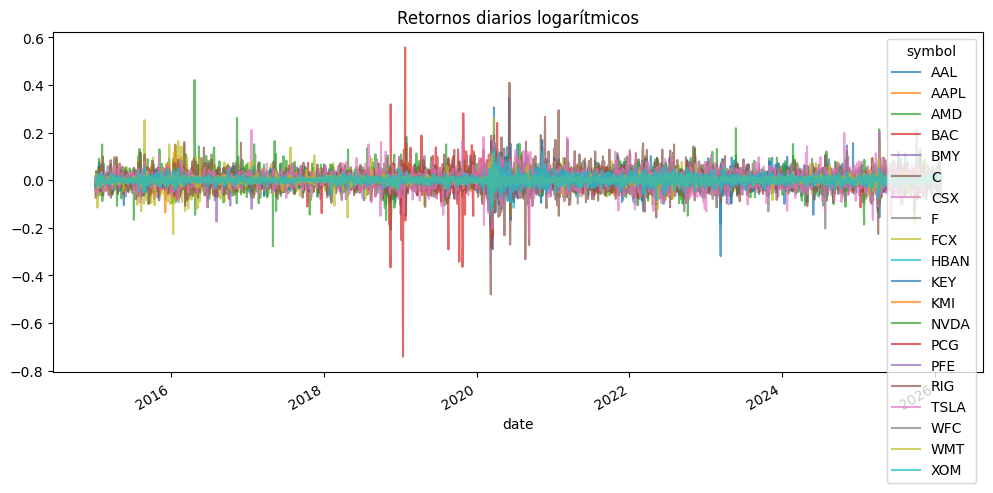

In [9]:
returns.plot(figsize=(12, 5), legend=True, title="Retornos diarios logarítmicos", alpha=0.7)
plt.show()

## 7. Sanity check: valores extremos y calidad de los datos

Antes de pasar estos datos a los modelos generativos, comprobamos que no hay
huecos (NaN) inesperados y revisamos los movimientos más extremos, para
distinguir errores de datos de eventos reales.

In [10]:
print("Valores NaN por activo:")
print(returns.isna().sum())
print("\nEstadísticos descriptivos:")
returns.describe().T[["mean", "std", "min", "max"]]

Valores NaN por activo:
symbol
AAL     0
AAPL    0
AMD     0
BAC     0
BMY     0
C       0
CSX     0
F       0
FCX     0
HBAN    0
KEY     0
KMI     0
NVDA    0
PCG     0
PFE     0
RIG     0
TSLA    0
WFC     0
WMT     0
XOM     0
dtype: int64

Estadísticos descriptivos:


,mean,std,min,max
symbol,,,,
AAL,-0.000483,0.031833,-0.290682,0.344278
AAPL,0.000851,0.018121,-0.137708,0.142618
AMD,0.001608,0.036391,-0.277456,0.420617
BAC,0.000474,0.019332,-0.167205,0.163786
BMY,0.000103,0.015904,-0.174176,0.108338
C,0.000378,0.020647,-0.214414,0.165381
CSX,0.000475,0.017514,-0.169017,0.210263
F,0.000173,0.022442,-0.202868,0.210596
FCX,0.000384,0.033987,-0.227311,0.259935


In [11]:
# Movimientos diarios extremos (|retorno| > 30%), para revisar caso a caso
extreme_moves = returns[(returns.abs() > 0.30)].dropna(how="all")
extreme_moves

symbol,AAL,AAPL,AMD,BAC,BMY,C,CSX,F,FCX,HBAN,KEY,KMI,NVDA,PCG,PFE,RIG,TSLA,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,
2016-04-22,NaN,NaN,0.420617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-11-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.366380,NaN,NaN,NaN,NaN,NaN,NaN
2018-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.318761,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.741483,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.557289,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.343235,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.364643,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.479888,NaN,NaN,NaN,NaN
2020-03-24,0.306049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Nota sobre los movimientos extremos:** cada fila de la tabla anterior tiene
NaN en casi todas las columnas porque el filtro `|retorno| > 30%` solo se
cumple para un activo concreto en cada fecha; no indica ningún problema de
datos, es el comportamiento esperado al filtrar un DataFrame ancho.

Todos los movimientos extremos detectados corresponden a eventos de mercado
reales y documentados, no a errores de datos:
- **PCG, varios días 2018-2020:** bancarrota (Chapter 11) por responsabilidad
  en los incendios forestales de California.
- **AMD, 22-04-2016 (+42%):** resultados trimestrales muy por encima de lo
  esperado.
- **RIG, marzo y junio de 2020:** shock del petróleo/COVID (el crudo llegó a
  cotizar en negativo ese periodo).
- **AAL, marzo y junio de 2020:** rebotes especulativos de aerolíneas en plena
  volatilidad COVID.
- **HBAN, 13-03-2023 (-32%):** crisis de bancos regionales en EEUU (colapso
  de Silicon Valley Bank).

Se mantienen todos en el dataset: son ejemplos reales de los episodios de
estrés poco frecuentes que los modelos generativos deberían aprender a
reproducir. Si alguno introduce inestabilidad al entrenar los generativos,
se valorará su tratamiento (winsorización, exclusión puntual) en ese momento.

## 8. Matriz de correlaciones

Sirve para confirmar que existe estructura sectorial real en los datos (los
activos del mismo sector deberían correlacionar más entre sí que con el resto),
lo cual justifica poder simular después shocks sectoriales controlados.

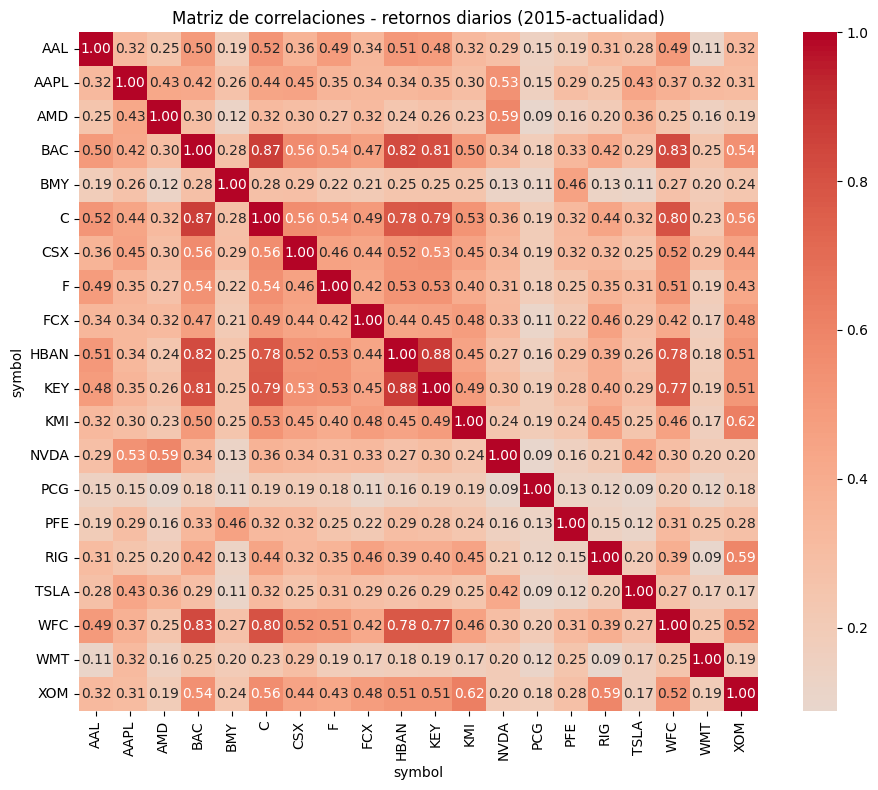

In [12]:
corr = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlaciones - retornos diarios (2015-actualidad)")
plt.tight_layout()
plt.show()

**Lectura del heatmap:** se confirma la estructura sectorial esperada, lo que
justifica poder simular después shocks sectoriales controlados.

- **Bancos (BAC, C, HBAN, KEY, WFC):** correlaciones muy altas entre sí
  (0.77-0.88), claramente el bloque más cohesionado de la matriz. Esto
  respalda que un "shock en el sector bancario" tenga sentido como
  perturbación conjunta sobre estos 5 activos.
- **Energía (XOM, KMI, RIG):** correlación moderada-alta (0.45-0.62), algo
  menos cohesionada que la banca pero claramente por encima del resto.
- **Tecnología (AAPL, AMD, NVDA):** correlación moderada (0.43-0.59).
- **PCG:** correlaciones bajas con el resto del universo (0.09-0.20) en casi
  todos los casos — coherente con que su comportamiento en el periodo esté
  dominado por un evento idiosincrático propio (la bancarrota) más que por
  el factor de mercado o su sector (utilities).
- **TSLA:** también relativamente descorrelacionada del resto, salvo con
  tecnología (AAPL 0.43, AMD 0.36), consistente con su perfil idiosincrático
  particular en este periodo.

Esta estructura será la base para la descomposición en factor común (mercado
y sector) + componente idiosincrático del Notebook 2.

## 9. Guardado del dataset procesado

In [13]:
returns.to_parquet("../data/processed/returns_daily.parquet")
print("Guardado en data/processed/returns_daily.parquet")
print(f"Shape final: {returns.shape}")

Guardado en data/processed/returns_daily.parquet
Shape final: (2785, 20)


## 10. Conclusión y decisiones tomadas

**Resumen de decisiones (16 agosto):**

1. **Fuente de datos:** S&P 500 (histórico proporcionado por Eugeni, 2015-actualidad),
   no el IBEX 35. Los ejemplos de shocks sectoriales de la propuesta original
   (Santander, Repsol) se adaptan a equivalentes del S&P 500 dentro de nuestro
   universo (bancos: BAC/WFC/C/HBAN/KEY; energía: XOM/KMI/RIG).

2. **Tamaño del universo:** 20 activos, no los 500 completos. La pregunta de
   investigación (¿ayudan los sintéticos a predecir mejor la matriz de
   covarianzas?) es una comparación interna entre métodos sobre el mismo
   conjunto de activos, y no requiere el universo completo.

3. **Selección por sector, no solo por liquidez:** 5 Financials, 3 Energy,
   3 Information Technology, 2 Health Care, 2 Consumer Discretionary,
   2 Industrials, 1 Consumer Staples, 1 Utilities, 1 Materials. Necesario
   para poder simular shocks sectoriales con sentido estadístico. La matriz
   de correlaciones confirma esta estructura: los bancos correlacionan entre
   0.77 y 0.88 entre sí (el bloque más cohesionado del universo), y energía
   entre 0.45 y 0.62 — evidencia empírica de que un shock sectorial conjunto
   sobre estos grupos tiene sentido estadístico.

4. **Universo fijo, no dinámico (sesgo de supervivencia asumido):** se exige
   histórico completo (~98% de cobertura) por activo. Esto excluye empresas
   que desaparecieron del todo del mercado, pero se asume conscientemente
   porque los generativos necesitan series alineadas sin huecos, y la
   comparación entre métodos afecta por igual a todos los brazos del
   experimento.

5. **Casos límite conservados:** el dataset incluye varios episodios reales
   de estrés de mercado, no filtrados ni suavizados: la bancarrota de PCG
   (2018-2020, caída máxima de -74% en un día), el shock del petróleo/COVID
   en RIG y AAL (marzo-junio 2020), la crisis de bancos regionales de 2023
   en HBAN, y un salto de resultados en AMD (2016). Se mantienen todos como
   ejemplos de eventos poco frecuentes que los modelos generativos deberían
   aprender a reproducir; se revisará su tratamiento (winsorización,
   exclusión puntual) si generan inestabilidad en el entrenamiento.

**Siguiente paso:** descomposición de cada serie en factor común (mercado /
sector) + componente idiosincrático, necesaria para poder generar escenarios
condicionados (Notebook 2).